# Predicting Which Tasks Are Repetitive

In this notebook, we implement a couple of machine learning models to predict whether tickets will be idenified as repetitive in the future — can we tell whether a ticket submission is likely to be re-submitted between 3 and 90 days, even if the maintenance hasn't been completed yet? In this notebook, we aim to answer these questions.

### Models
We try two classification machine learning models for classifying tickets as repetitive or non-repeititve: 
1. Random Forest
2. XGBoost

Confusion matrices are displayed to visualize classification accuracy, features with the highest importances are displayed as bar graphs. The XGBoost model is improved by using SMOTE and Threshold tuning.


In [1]:
import sys
import os
sys.path.append(os.path.abspath('../utils'))

import pandas as pd
import numpy as np
from data_aggregation_tools import merge_tickets_assets, convert_cols_to_datetime
from repetitive_tasks import detect_repetitive_objects

# Set dataframes to display all columns
pd.set_option('display.max_columns', None)

df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")

# Generate merged tickets / assets file
df_tickets_assets = merge_tickets_assets(df_tickets=df_tickets, df_assets=df_assets)
df_tickets_assets_spaces = convert_cols_to_datetime(df_tickets_assets)

# Drop rows without space attached
df_tickets_assets_spaces = df_tickets_assets.dropna(subset=['SPACE'])

print(f"shape of df_tickets: {df_tickets.shape}")
print(f"shape of df_assets: {df_assets.shape}")
print(f"shape of df_tickets_assets: {df_tickets_assets.shape}")
print(f"shape of df_tickets_assets_spaces: {df_tickets_assets_spaces.shape}")

# print(df_tickets_assets["CREATE_DATE_LTZ"].dtype) # <-- should return 'datetime64[ns]'
df_tickets_assets.head()

/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_90202/2552738253.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_90202/2552738253.py:14: DtypeWarning: Columns (0,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")


shape of df_tickets: (227205, 47)
shape of df_assets: (316257, 9)
shape of df_tickets_assets: (316257, 55)
shape of df_tickets_assets_spaces: (125227, 55)


,WORK_TASK_ID,WORK_TASK_NAME_ticket,WORK_TASK_STATUS_ticket,RICE_WORK_STATUS,ASSIGNMENT_STATUS,DESCRIPTION,TASK_TYPE,TASK_PRIORITY,REQUEST_CLASS,SERVICE_CLASS,PRIMARY_LOCATION,PROPERTY,BUILDING,FLOOR,SPACE,GEOGRAPHY_LOOKUP,CUSTOMER_ORGANIZATION,CUSTOMER_COMPANY,CUSTOMER_DIVISION,CUSTOMER_DEPARTMENT,RESPONSIBLE_ORGANIZATION_NAME,ORGANIZATION_TYPE,RESPONSIBLE_ORGANIZATION_PATH,RESPONSIBLE_PERSON_NAME,RESPONSIBLE_PERSON_EMAIL,RESPONSIBLE_PERSON_WORKPHONE,BASELINE_START_LTZ,BASELINE_END_LTZ,ASSIGNED_DATE_LTZ,PLANNED_START_LTZ,PLANNED_END_LTZ,PLANNED_FOLLOW_UP_DATE_LTZ,PLANNED_WORKING_DAYS,PLANNED_COST,ACTUAL_START_LTZ,ACTUAL_END_LTZ,RICE_ACTUAL_COST,REVERSAL,BILLING_TYPE,ACCOUNTING_HOLD,ACCOUNTING_HOLD_REASON,COA_ACCOUNT_STRING,POETAF_ACCOUNT_STRING,NUMBER_OF_ASSETS,RESOLUTION_DESCRIPTION,CAPITAL_PROJECT_ID,CREATE_DATE_LTZ,WORK_TASK_NAME_asset,WORK_TASK_STATUS_asset,ASSET_ID,ASSET_NAME,ASSET_STATUS,ASSET_PRIMARY_LOCATION,ASSET_PRIMARY_LOCATION_BUILDING,ACCOUNT_STRING
0,1302351,RICE - DEFAULT - Work Task Template - Correcti...,Completed,Work Done,Completed,student at Jones North room 129 has hand foot ...,Corrective,3 - Routine,Custodial Issues,Custodial,\Locations\Rice\Mary Gibbs Jones College - Nor...,Rice,Mary Gibbs Jones College - North,01,129,\Geography\North America\United States\Texas\H...,\Organizations\Rice\Dean of Undergraduates\Stu...,Rice,Dean of Undergraduates,Student Health Services,HD Custodial,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Melissa Salinas,melissasalinas@rice.edu,713-348-8264,2025-09-19 08:24:42,2025-10-10 08:24:42,2025-09-19 08:24:45,2025-09-19 08:24:42,2025-10-10 08:24:42,2025-09-21 08:24:42,21,NaN,2025-09-19 08:24:42,2025-09-22 10:36:51,0.0,False,Billable,No,NaN,"10,84100,103,030000,8985,800,9999,9999,999,999",NaN,0,NaN,NaN,2025-09-19 08:24:42,RICE - DEFAULT - Work Task Template - Correcti...,Completed,NaN,NaN,NaN,NaN,NaN,NaN
1,1302352,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management Support,Capital Projects,\Locations\Rice\George R. Brown Hall,Rice,George R. Brown Hall,NaN,NaN,\Geography\North America\United States\Texas\H...,NaN,NaN,NaN,NaN,00 FE&P Administration,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Pamela Marut,pm12@rice.edu,NaN,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,2025-09-19 08:30:07,0,NaN,2025-09-19 08:30:07,2026-01-14 08:38:10,0.0,False,Billable,No,NaN,"10,00100,100,000000,1087,500,9999,9999,999,999","C10000442,86000,NC Project Management Support ...",0,NaN,C10000442,2025-09-19 08:30:07,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,NaN,NaN,NaN,NaN,NaN,NaN
2,1302353,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management Support,Capital Projects,\Locations\Rice\George R. Brown Hall,Rice,George R. Brown Hall,NaN,NaN,\Geography\North America\United States\Texas\H...,NaN,NaN,NaN,NaN,14 Facilities Project Managers,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Troy Christmas,Troy.W.Christmas@rice.edu,NaN,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,2025-09-19 08:30:12,0,NaN,2025-09-19 08:30:12,2026-01-14 08:38:21,0.0,False,Billable,No,NaN,"10,00100,100,000000,1087,999,9999,9999,999,999","C10000442,86000,NC Project Management Support ...",0,NaN,C10000442,2025-09-19 08:30:12,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,NaN,NaN,NaN,NaN,NaN,NaN
3,1302354,C10000442-GRB 2nd and 3rd Floor Autoclave Reno...,Closed,Work Done,Completed,NaN,NaN,0 - Admin,Project Management,Capital Projects,\Locations\Rice\George R. Brown Hall,Rice,George R. Brown Hall,NaN,NaN,\Geography\North America\United States\Texas\H...,NaN,NaN,NaN,NaN,15 Capital Project Managers,Workgroup,\Organizations\DEFAULT Workgroup (for Default ...,Laura Thurmond,Laura.Thurmond@rice.edu,NaN,2025-09-19 08:30:17,2025-09-19 08:30:17,2025-09-

In [2]:
# Define objects and find the repetitive objects

num_days = 90
group_cols = ['SERVICE_CLASS', 'BUILDING', 'FLOOR', 'SPACE']
df_tickets_filtered_by_object, object_repetitive_dict, all_objects_dict = detect_repetitive_objects(df_tickets_assets_spaces, group_cols, num_days, verbose=True)

90 days 00:00:00
Number of columns pre-corrective: 125227
Number of corrective tasks: 69004
Number of unique objects (groups): 29222
Found 14684 repetitive tasks by object within 90 days.


In [3]:
print(df_tickets_assets_spaces.index[:5])
print([idx for indices in object_repetitive_dict.values() for idx in indices][:5])

Index([0, 10, 11, 12, 13], dtype='int64')
[3, 8, 9, 12, 2084]


## Implement Random Forest & XGBoost Models

Here, we will try two machine learning strategies for determining what causes a task to be classified as repetitive, based on our object definition we defined in `repetitive_objects.ipynb`.

We aim to determine which features (columns of the merged ticket/asset data) are most important in predicting whether a task will be repetitive.

### 1. Random Forest



/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_90202/198974562.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tickets_assets_spaces['is_repetitive'] = df_tickets_assets_spaces.index.isin(
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_90202/198974562.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tickets_assets_spaces['day_of_week'] = df_tickets_assets_spaces['CREATE_DATE_LTZ'].dt.dayofweek
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_90202/198974562.p


Missing values per feature:
SERVICE_CLASS                     2162
REQUEST_CLASS                        0
BUILDING                             0
FLOOR                                0
SPACE                                0
PROPERTY                             0
GEOGRAPHY_LOOKUP                     1
NUMBER_OF_ASSETS                     0
RESPONSIBLE_ORGANIZATION_NAME      128
ORGANIZATION_TYPE                  128
CUSTOMER_ORGANIZATION              563
CUSTOMER_DIVISION                  564
CUSTOMER_DEPARTMENT                563
TASK_TYPE                           14
TASK_PRIORITY                       97
WORK_TASK_STATUS_ticket              0
RICE_WORK_STATUS                     4
ASSIGNMENT_STATUS                    0
BILLING_TYPE                     12147
PLANNED_WORKING_DAYS                 5
day_of_week                          0
month                                0
quarter                              0
day_of_month                         0
week_of_year                       

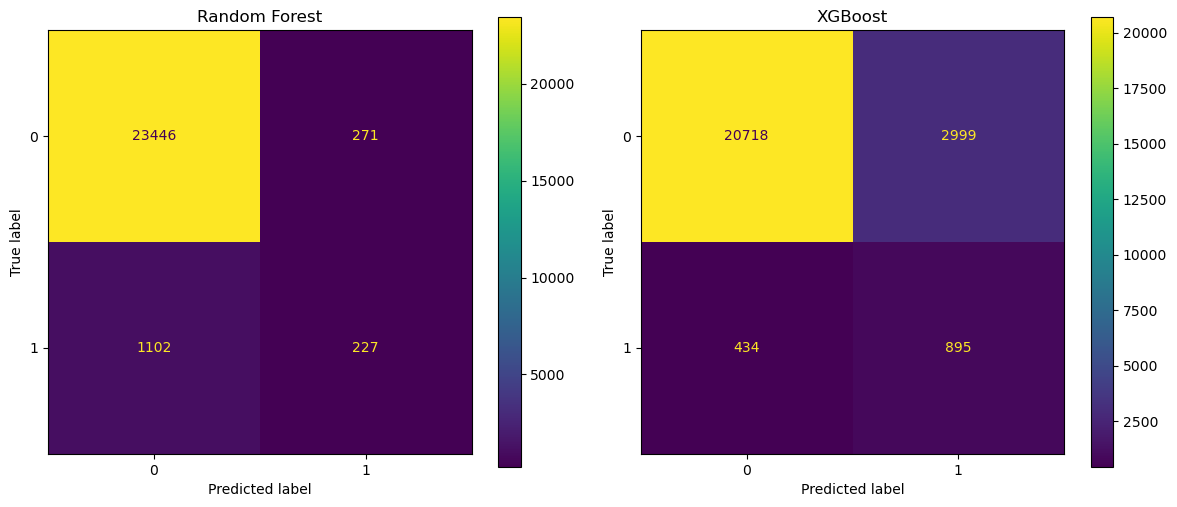

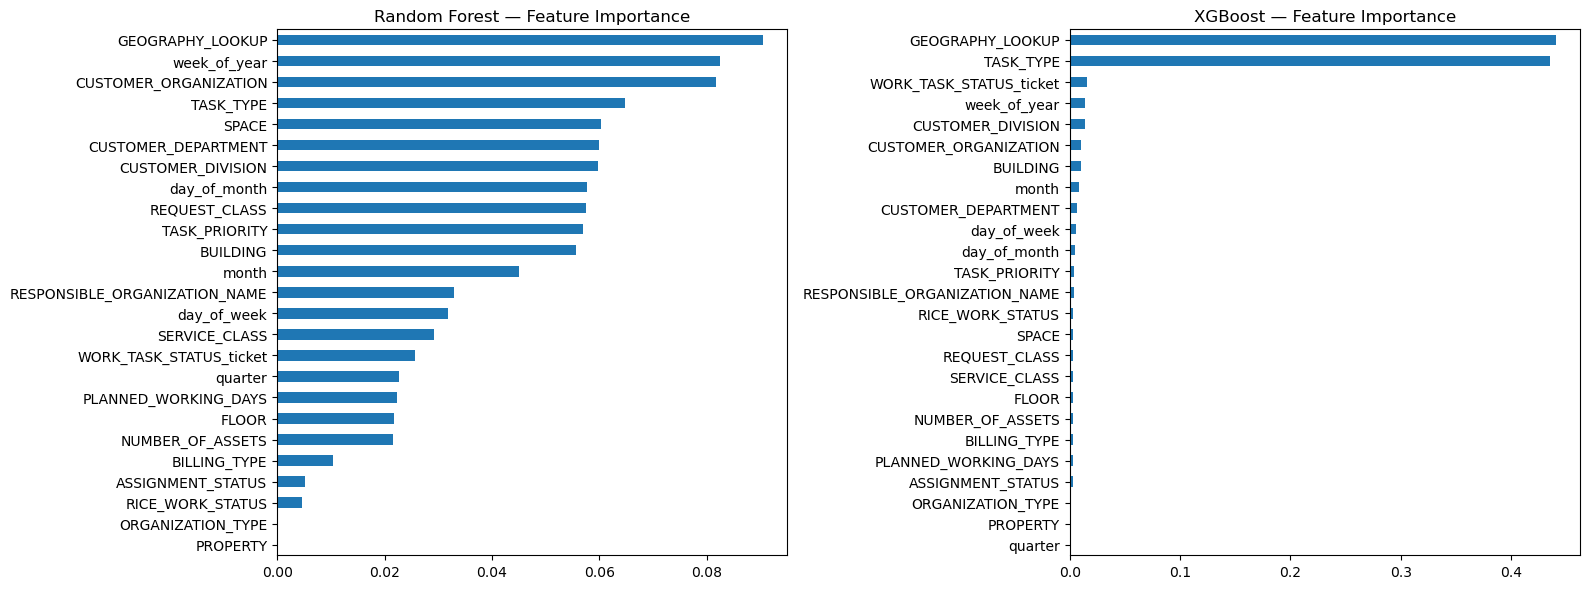

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer


#  Step 1. Labeling (check if the row is in object_repetitive_dict)
df_tickets_assets_spaces['is_repetitive'] = df_tickets_assets_spaces.index.isin(
    [idx for indices in object_repetitive_dict.values() for idx in indices]
).astype(int)

## To ensure that the 'is_repetitive' column of df_tickets_assets_spaes was correctly added
# print('is_repetitive' in df_tickets_assets_spaces.columns)

# Step 2. Define extra "temporal" columns that might identify cycles in our data
df_tickets_assets_spaces['day_of_week'] = df_tickets_assets_spaces['CREATE_DATE_LTZ'].dt.dayofweek
df_tickets_assets_spaces['month']       = df_tickets_assets_spaces['CREATE_DATE_LTZ'].dt.month
df_tickets_assets_spaces['quarter']     = df_tickets_assets_spaces['CREATE_DATE_LTZ'].dt.quarter
df_tickets_assets_spaces['day_of_month'] = df_tickets_assets_spaces['CREATE_DATE_LTZ'].dt.day
df_tickets_assets_spaces['week_of_year'] = df_tickets_assets_spaces['CREATE_DATE_LTZ'].dt.isocalendar().week

# Step 3. Encode + split
feature_cols = [
    # Location & Asset Info
    'SERVICE_CLASS', 
    'REQUEST_CLASS', 
    'BUILDING', 
    'FLOOR', 
    'SPACE',
    'PROPERTY',
    'GEOGRAPHY_LOOKUP',
    'NUMBER_OF_ASSETS',
    
    # Organizational Context
    'RESPONSIBLE_ORGANIZATION_NAME', 
    'ORGANIZATION_TYPE',
    'CUSTOMER_ORGANIZATION',
    'CUSTOMER_DIVISION',
    'CUSTOMER_DEPARTMENT',
    
    # Task Characteristics
    'TASK_TYPE',
    'TASK_PRIORITY',
    'WORK_TASK_STATUS_ticket',
    'RICE_WORK_STATUS',
    'ASSIGNMENT_STATUS',
    
    # Financial/Billing
    'BILLING_TYPE',
    
    # Temporal Features
    'PLANNED_WORKING_DAYS',
    'day_of_week', 
    'month', 
    'quarter',
    'day_of_month',
    'week_of_year',

    # Preventative maintenance
    
]

df_model = df_tickets_assets_spaces[feature_cols + ['is_repetitive']].copy()

# Handle missing values BEFORE encoding
print("\nMissing values per feature:")
print(df_model[feature_cols].isnull().sum())

# Encode all object columns
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Implement the inputs & labels
X = df_model[feature_cols]
y = df_model['is_repetitive']

print(f"\nClass balance — Non-repetitive: {(y==0).sum()} | Repetitive: {(y==1).sum()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# We need to use an imputer because we have some NaN values in our features!
imputer = SimpleImputer(strategy='most_frequent') # Replace NaN values with the most common value in that column
X_train = imputer.fit_transform(X_train) # Scan X_train to learn the most frequent value for each column
X_test = imputer.transform(X_test) # Replace all NaNs in X_train with those learned values ^^


# Step 4. Train both models 
scale = (y_train == 0).sum() / (y_train == 1).sum() # Calculate the ratio of non-repetitive to repetitive tasks in the training set

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=200,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

rf.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print(f"\nRandom Forest trained with {len(feature_cols)} features")
print(f"XGBoost trained with {len(feature_cols)} features")

# Step 5. Evaluate 
y_pred_rf  = rf.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

print("\n────────────── Random Forest: ────────────────")
print(classification_report(y_test, y_pred_rf))

print("─────────────────── XGBoost: ───────────────────")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,  ax=ax1)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=ax2)
ax1.set_title('Random Forest')
ax2.set_title('XGBoost')
plt.tight_layout()
plt.show()

# Step 6. Feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
rf_importance.plot(kind='barh', ax=ax1)
ax1.set_title('Random Forest — Feature Importance')

# XGBoost
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
xgb_importance.plot(kind='barh', ax=ax2)
ax2.set_title('XGBoost — Feature Importance')

plt.tight_layout()
plt.show()

## This Model Does Not Effectively Detect Repetitive Tasks.

Instead, let's try some threshold tuning:

### Try Logistic Regression

- SMOTE 
- 


BEFORE resampling:
  Class 0: 95075
  Class 1: 5106

AFTER resampling:
  Class 0: 95075
  Class 1: 33276
  Ratio: 2.86:1

Training Random Forest on resampled data...
Training XGBoost on resampled data...

THRESHOLD TUNING

Random Forest optimal threshold: 0.6586 (F1: 0.3734)
XGBoost optimal threshold: 0.8181 (F1: 0.3825)

RESULTS: SMOTE + THRESHOLD TUNING

────────────── Random Forest (SMOTE + Threshold): ────────────────
              precision    recall  f1-score   support

           0       0.97      0.92      0.95     23717
           1       0.28      0.57      0.37      1329

    accuracy                           0.90     25046
   macro avg       0.63      0.74      0.66     25046
weighted avg       0.94      0.90      0.91     25046

ROC-AUC: 0.9051 | PR-AUC: 0.3379

─────────────────── XGBoost (SMOTE + Threshold): ───────────────────
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     23717
           1       0.40      0.37  

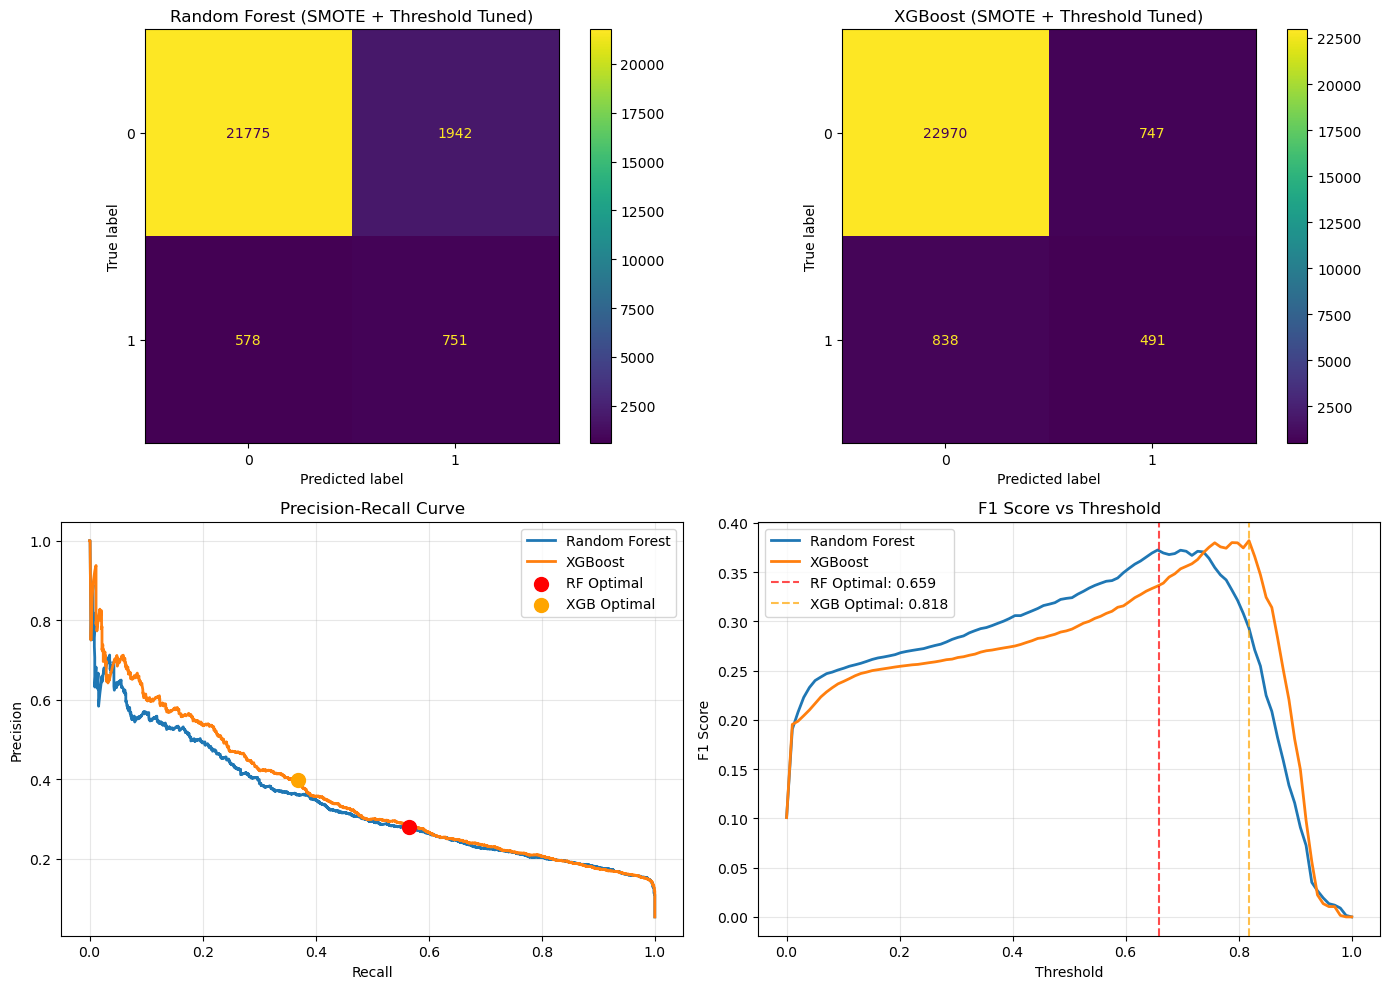

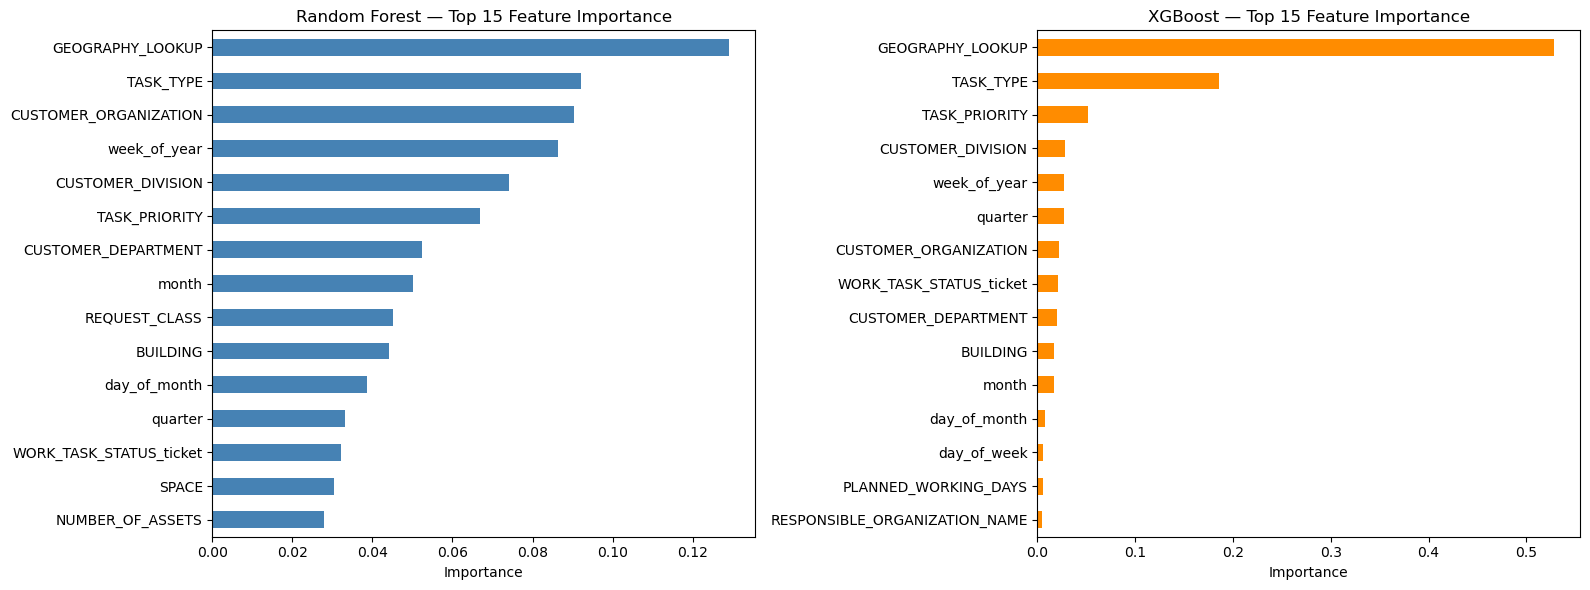


TOP 10 FEATURES BY IMPORTANCE

Random Forest:
GEOGRAPHY_LOOKUP         0.129191
TASK_TYPE                0.092183
CUSTOMER_ORGANIZATION    0.090318
week_of_year             0.086356
CUSTOMER_DIVISION        0.074119
TASK_PRIORITY            0.066871
CUSTOMER_DEPARTMENT      0.052259
month                    0.050199
REQUEST_CLASS            0.045118
BUILDING                 0.044193
dtype: float64

XGBoost:
GEOGRAPHY_LOOKUP           0.528471
TASK_TYPE                  0.185389
TASK_PRIORITY              0.051600
CUSTOMER_DIVISION          0.028358
week_of_year               0.027727
quarter                    0.027470
CUSTOMER_ORGANIZATION      0.022447
WORK_TASK_STATUS_ticket    0.021522
CUSTOMER_DEPARTMENT        0.019948
BUILDING                   0.017535
dtype: float32


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, precision_recall_curve, roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# For resampling the minority class (repetitive tickets)
from sklearn.utils import resample

print("BEFORE resampling:")
print(f"  Class 0: {(y_train==0).sum()}")
print(f"  Class 1: {(y_train==1).sum()}")

# Separate majority and minority
X_train_maj = X_train[y_train == 0]
y_train_maj = y_train[y_train == 0]
X_train_min = X_train[y_train == 1]
y_train_min = y_train[y_train == 1]

# Oversample minority class to 30% of dataset
target_count = int((y_train == 0).sum() * 0.35)
X_train_min_resampled, y_train_min_resampled = resample(
    X_train_min, y_train_min,
    n_samples=target_count,
    random_state=42,
    replace=True
)

# Combine
X_train_balanced = np.vstack([X_train_maj, X_train_min_resampled])
y_train_balanced = np.hstack([y_train_maj, y_train_min_resampled])

print("\nAFTER resampling:")
print(f"  Class 0: {(y_train_balanced==0).sum()}")
print(f"  Class 1: {(y_train_balanced==1).sum()}")
print(f"  Ratio: {(y_train_balanced==0).sum() / (y_train_balanced==1).sum():.2f}:1")

# ============================================================================
# TRAIN MODELS ON RESAMPLED DATA
# ============================================================================

scale_balanced = (y_train_balanced == 0).sum() / (y_train_balanced == 1).sum()

rf_smote = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

xgb_smote = XGBClassifier(
    scale_pos_weight=scale_balanced,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

print("\nTraining Random Forest on resampled data...")
rf_smote.fit(X_train_balanced, y_train_balanced)

print("Training XGBoost on resampled data...")
xgb_smote.fit(X_train_balanced, y_train_balanced)

# ============================================================================
# GET PROBABILITY PREDICTIONS (needed for threshold tuning)
# ============================================================================

y_pred_rf_proba = rf_smote.predict_proba(X_test)[:, 1]
y_pred_xgb_proba = xgb_smote.predict_proba(X_test)[:, 1]

# ============================================================================
# FIND OPTIMAL THRESHOLD
# ============================================================================

print("\n" + "="*70)
print("THRESHOLD TUNING")
print("="*70)

# For Random Forest
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_pred_rf_proba)
f1_scores_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf + 1e-10)
optimal_idx_rf = np.argmax(f1_scores_rf)
optimal_threshold_rf = thresholds_rf[optimal_idx_rf]

# For XGBoost
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_pred_xgb_proba)
f1_scores_xgb = 2 * (precision_xgb * recall_xgb) / (precision_xgb + recall_xgb + 1e-10)
optimal_idx_xgb = np.argmax(f1_scores_xgb)
optimal_threshold_xgb = thresholds_xgb[optimal_idx_xgb]

print(f"\nRandom Forest optimal threshold: {optimal_threshold_rf:.4f} (F1: {f1_scores_rf[optimal_idx_rf]:.4f})")
print(f"XGBoost optimal threshold: {optimal_threshold_xgb:.4f} (F1: {f1_scores_xgb[optimal_idx_xgb]:.4f})")

# Apply optimal thresholds
y_pred_rf_tuned = (y_pred_rf_proba >= optimal_threshold_rf).astype(int)
y_pred_xgb_tuned = (y_pred_xgb_proba >= optimal_threshold_xgb).astype(int)

# ============================================================================
# EVALUATION
# ============================================================================

print("\n" + "="*70)
print("RESULTS: SMOTE + THRESHOLD TUNING")
print("="*70)

print("\n────────────── Random Forest (SMOTE + Threshold): ────────────────")
print(classification_report(y_test, y_pred_rf_tuned))
rf_roc_auc = roc_auc_score(y_test, y_pred_rf_proba)
rf_pr_auc = average_precision_score(y_test, y_pred_rf_proba)
print(f"ROC-AUC: {rf_roc_auc:.4f} | PR-AUC: {rf_pr_auc:.4f}")

print("\n─────────────────── XGBoost (SMOTE + Threshold): ───────────────────")
print(classification_report(y_test, y_pred_xgb_tuned))
xgb_roc_auc = roc_auc_score(y_test, y_pred_xgb_proba)
xgb_pr_auc = average_precision_score(y_test, y_pred_xgb_proba)
print(f"ROC-AUC: {xgb_roc_auc:.4f} | PR-AUC: {xgb_pr_auc:.4f}")

# ============================================================================
# CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_tuned, ax=axes[0, 0])
axes[0, 0].set_title('Random Forest (SMOTE + Threshold Tuned)')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_tuned, ax=axes[0, 1])
axes[0, 1].set_title('XGBoost (SMOTE + Threshold Tuned)')

# Precision-Recall curves
axes[1, 0].plot(recall_rf, precision_rf, label='Random Forest', linewidth=2)
axes[1, 0].plot(recall_xgb, precision_xgb, label='XGBoost', linewidth=2)
axes[1, 0].scatter([recall_rf[optimal_idx_rf]], [precision_rf[optimal_idx_rf]], s=100, color='red', label='RF Optimal', zorder=5)
axes[1, 0].scatter([recall_xgb[optimal_idx_xgb]], [precision_xgb[optimal_idx_xgb]], s=100, color='orange', label='XGB Optimal', zorder=5)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1 scores across thresholds
thresholds_range = np.linspace(0, 1, 100)
f1_rf_range = []
f1_xgb_range = []

for thresh in thresholds_range:
    y_pred_rf_temp = (y_pred_rf_proba >= thresh).astype(int)
    y_pred_xgb_temp = (y_pred_xgb_proba >= thresh).astype(int)
    
    from sklearn.metrics import f1_score
    f1_rf_range.append(f1_score(y_test, y_pred_rf_temp, zero_division=0))
    f1_xgb_range.append(f1_score(y_test, y_pred_xgb_temp, zero_division=0))

axes[1, 1].plot(thresholds_range, f1_rf_range, label='Random Forest', linewidth=2)
axes[1, 1].plot(thresholds_range, f1_xgb_range, label='XGBoost', linewidth=2)
axes[1, 1].axvline(optimal_threshold_rf, color='red', linestyle='--', alpha=0.7, label=f'RF Optimal: {optimal_threshold_rf:.3f}')
axes[1, 1].axvline(optimal_threshold_xgb, color='orange', linestyle='--', alpha=0.7, label=f'XGB Optimal: {optimal_threshold_xgb:.3f}')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score vs Threshold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rf_importance = pd.Series(rf_smote.feature_importances_, index=feature_cols).sort_values(ascending=True)
rf_importance.tail(15).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Random Forest — Top 15 Feature Importance')
ax1.set_xlabel('Importance')

xgb_importance = pd.Series(xgb_smote.feature_importances_, index=feature_cols).sort_values(ascending=True)
xgb_importance.tail(15).plot(kind='barh', ax=ax2, color='darkorange')
ax2.set_title('XGBoost — Top 15 Feature Importance')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("TOP 10 FEATURES BY IMPORTANCE")
print("="*70)
print("\nRandom Forest:")
print(rf_importance.sort_values(ascending=False).head(10))
print("\nXGBoost:")
print(xgb_importance.sort_values(ascending=False).head(10))

## WIP For Later: Checking Objects for Preventative Work

Disregard for now...

In [ ]:
# # Step 1. Create an object identifier column (matches the keys in all_objects_dict)
# # Based on your dictionary structure: 'SERVICE_CLASS | BUILDING | FLOOR | SPACE'
# df_tickets_assets_spaces['object_id'] = (
#     df_tickets_assets_spaces['SERVICE_CLASS'].astype(str) + ' | ' +
#     df_tickets_assets_spaces['BUILDING'].astype(str) + ' | ' +
#     df_tickets_assets_spaces['FLOOR'].astype(str) + ' | ' +
#     df_tickets_assets_spaces['SPACE'].astype(str)
# )

# # Verify that some of these object IDs exist in all_objects_dict
# print("Sample object IDs:")
# print(df_tickets_assets_spaces['object_id'].head(10))

# print("\nChecking if object_ids exist in all_objects_dict:")
# sample_objects = df_tickets_assets_spaces['object_id'].head(5)
# for obj in sample_objects:
#     exists = obj in all_objects_dict
#     print(f"  {obj[:50]:50s} → {exists}")

# # Step 2. Create the preventative_maintenance_performed feature
# # For each row, check if there was a preventative task for the same object BEFORE this task's date

# df_tickets_assets_spaces['preventative_maintenance_performed'] = False

# for idx, row in df_tickets_assets_spaces.iterrows():
#     current_object = row['object_id']
#     current_date = row['CREATE_DATE_LTZ']
#     current_task_type = row['TASK_TYPE']
    
#     # Get all previous tasks for this same object
#     previous_tasks = df_tickets_assets_spaces[
#         (df_tickets_assets_spaces['object_id'] == current_object) &
#         (df_tickets_assets_spaces['CREATE_DATE_LTZ'] < current_date)
#     ]
    
#     # Check if any of these previous tasks were preventative maintenance
#     has_preventative = (previous_tasks['TASK_TYPE'] == 'Preventative').any()
    
#     df_tickets_assets_spaces.loc[idx, 'preventative_maintenance_performed'] = has_preventative
    
#     # Progress indicator for long-running operations
#     if (idx + 1) % 10000 == 0:
#         print(f"Processed {idx + 1} rows...")

# print(f"\nFeature created!")
# print(f"Preventative maintenance performed: {df_tickets_assets_spaces['preventative_maintenance_performed'].sum()} rows")
# print(f"No preventative maintenance: {(~df_tickets_assets_spaces['preventative_maintenance_performed']).sum()} rows")


# # ADD MORE TO THIS LATER (i.e. keywords)
# feature_cols = [
#     # Location & Asset Info
#     'SERVICE_CLASS', 
#     'REQUEST_CLASS', 
#     'BUILDING', 
#     'FLOOR', 
#     'SPACE',
#     'PROPERTY',
#     'GEOGRAPHY_LOOKUP',
#     'NUMBER_OF_ASSETS',
    
#     # Organizational Context
#     'RESPONSIBLE_ORGANIZATION_NAME', 
#     'ORGANIZATION_TYPE',
#     'CUSTOMER_ORGANIZATION',
#     'CUSTOMER_DIVISION',
#     'CUSTOMER_DEPARTMENT',
    
#     # Task Characteristics
#     'TASK_TYPE',
#     'TASK_PRIORITY',
#     'WORK_TASK_STATUS_ticket',
#     'RICE_WORK_STATUS',
#     'ASSIGNMENT_STATUS',
    
#     # Financial/Billing
#     'BILLING_TYPE',
    
#     # Temporal Features
#     'PLANNED_WORKING_DAYS',
#     'day_of_week', 
#     'month', 
#     'quarter',
#     'day_of_month',
#     'week_of_year',
    
#     # NEW FEATURE
#     'preventative_maintenance_performed',
# ]

# print(f"\nUpdated feature_cols with {len(feature_cols)} features")
# print(f"New column added: preventative_maintenance_performed")

/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_90202/1855313263.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tickets_assets_spaces['object_id'] = (
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_90202/1855313263.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tickets_assets_spaces['preventative_maintenance_performed'] = False


Sample object IDs:
0     Custodial | Mary Gibbs Jones College - North |...
10    Electrical | Bioscience Research Collaborative...
11    Carpentry | Bioscience Research Collaborative ...
12    Plumbing | Burton and Deedee McMurtry College ...
13    Moving Equipment | Space Science and Technolog...
15        Building Interior | Herzstein Hall | 02 | 210
18    Event Support | Facilities Engineering and Pla...
21    Building Automation Systems | Fondren Library ...
23               Mechanical | Martel College | 03 | 322
24        Access Control | Dell Butcher Hall | 03 | 300
Name: object_id, dtype: object

Checking if object_ids exist in all_objects_dict:
  Custodial | Mary Gibbs Jones College - North | 01  → True
  Electrical | Bioscience Research Collaborative | 0 → True
  Carpentry | Bioscience Research Collaborative | 02 → True
  Plumbing | Burton and Deedee McMurtry College | 03 → True
  Moving Equipment | Space Science and Technology |  → True
Processed 10000 rows...
Processed 20000